In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [7]:
# PART 1: LOAD DATA
try:
    df = pd.read_csv('data1.csv')
    print("Dataset 'dat1a.csv' loaded successfully.\n")
except FileNotFoundError:
    print("Error: Please save the provided data as 'data.csv' first.")
    exit()

nutrients = ['DMI', 'TDN', 'ME', 'CP', 'DP', 'Ca', 'P']


Dataset 'dat1a.csv' loaded successfully.



In [9]:
# PART 2: EXPLORATORY DATA ANALYSIS (EDA)
print("--- Part 2: Summary Statistics ---")
print(df.describe().T[['mean', 'std', 'min', '25%', '50%','75%' ,'max']])



--- Part 2: Summary Statistics ---
            mean          std      min       25%       50%        75%  \
BW     48.774286    40.901362    5.200   10.4000    38.000    79.9500   
ADG     0.613514     0.322041    0.187    0.2975     0.629     0.8940   
DMI     2.554200     2.252604    0.275    0.4655     1.816     4.1215   
TDN  1480.667743  1155.887852  233.938  354.7420  1122.361  2631.8825   
ME      7.665057     6.409306    0.829    1.4375     5.907    12.6955   
CP    220.193629   116.615692   58.028  106.6545   220.337   335.0120   
DP    201.474771   112.262834   47.090   81.4525   219.490   310.2770   
Ca     17.057657    13.994523    2.621    3.9670    12.843    27.1220   
P      11.515857     9.612621    1.703    2.5945     9.004    19.3175   

          max  
BW    132.100  
ADG     1.200  
DMI     7.805  
TDN  3722.474  
ME     19.694  
CP    388.766  
DP    370.465  
Ca     47.118  
P      35.620  


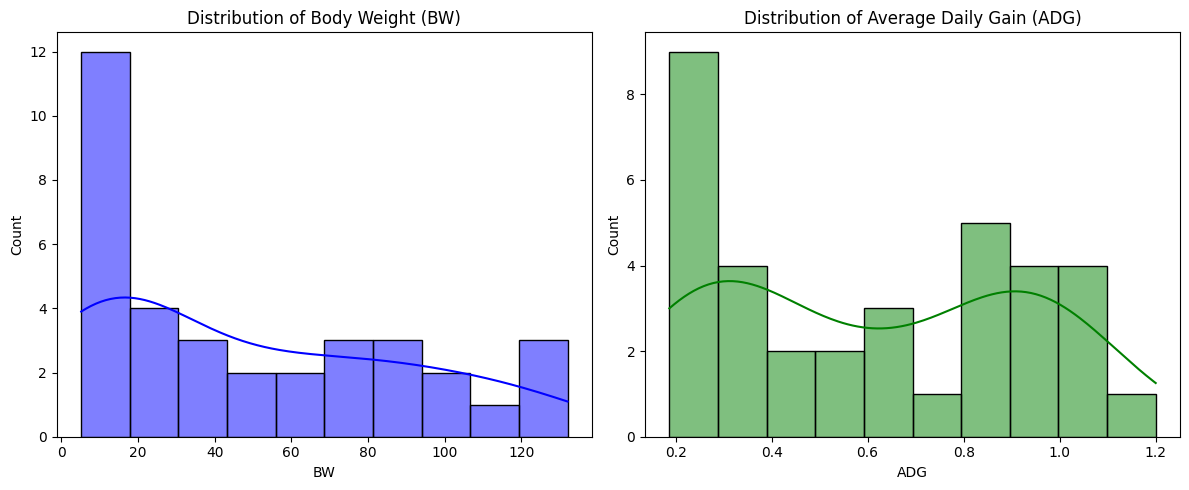

In [11]:
# 1. Histograms for BW and ADG
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['BW'], kde=True, color='blue', bins=10)
plt.title('Distribution of Body Weight (BW)')

plt.subplot(1, 2, 2)
sns.histplot(df['ADG'], kde=True, color='green', bins=10)
plt.title('Distribution of Average Daily Gain (ADG)')
plt.tight_layout()
plt.show()

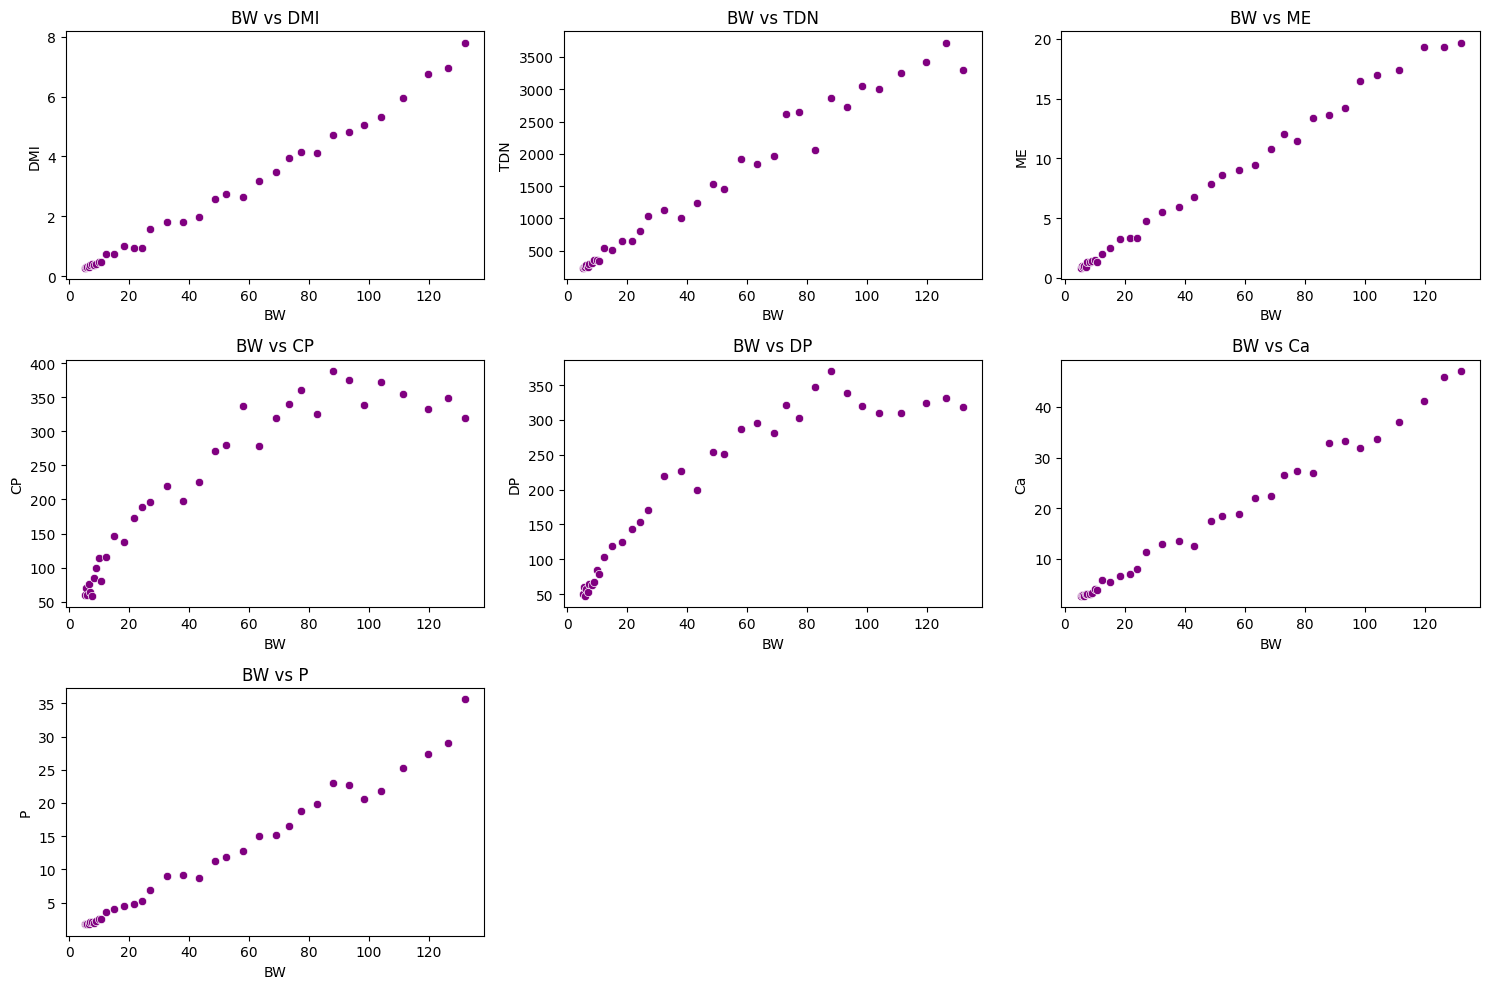

In [13]:
# 2. Scatter plots (BW vs Nutrients)
plt.figure(figsize=(15, 10))
for i, nut in enumerate(nutrients, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(x=df['BW'], y=df[nut], color='purple')
    plt.title(f'BW vs {nut}')
plt.tight_layout()
plt.show()


--- Part 3: Correlation Analysis ---


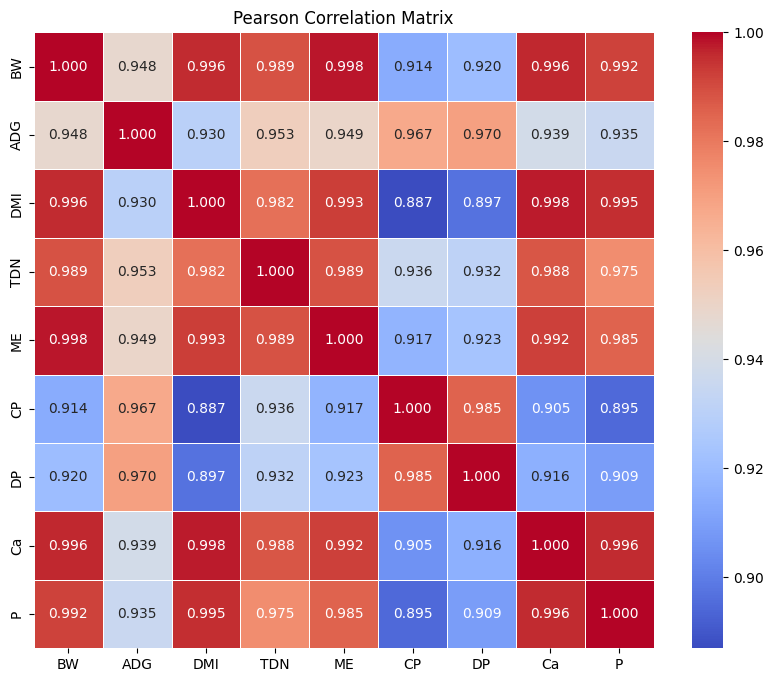

In [15]:
# ==========================================
# PART 3: CORRELATION ANALYSIS
# ==========================================
print("\n--- Part 3: Correlation Analysis ---")
corr_matrix = df.corr()

# Plot Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Pearson Correlation Matrix')
plt.show()


--- Part 4 & 5: Regression Model Evaluations ---


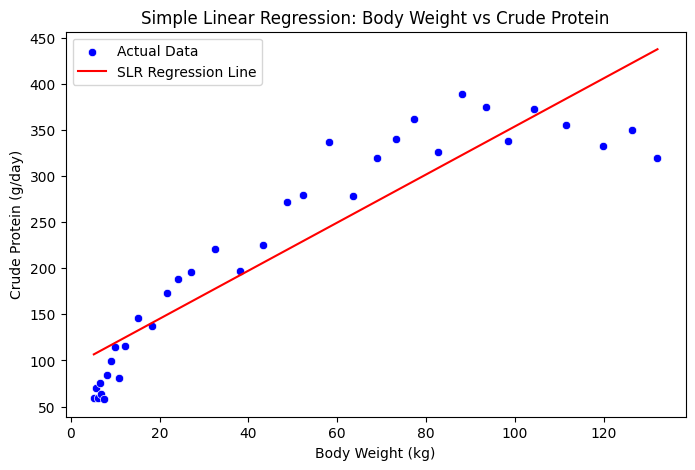

In [17]:
# PART 4 & 5: LINEAR REGRESSION MODELS
print("\n--- Part 4 & 5: Regression Model Evaluations ---")
X_simple = df[['BW']]
X_multi = df[['BW', 'ADG']]

slr_models = {}
mlr_models = {}

# We will use Crude Protein (CP) ad Metabolizable Energy (ME) as our primary focus for printing
target_y = df['CP']

# Simple Linear Regression (CP = a + b*BW)
slr = LinearRegression().fit(X_simple, target_y)
y_pred_slr = slr.predict(X_simple)
slr_models['CP'] = slr

# Plot Simple Linear Regression line
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['BW'], y=df['CP'], color='blue', label='Actual Data')
plt.plot(df['BW'], y_pred_slr, color='red', label='SLR Regression Line')
plt.title('Simple Linear Regression: Body Weight vs Crude Protein')
plt.xlabel('Body Weight (kg)')
plt.ylabel('Crude Protein (g/day)')
plt.legend()
plt.show()

# Multiple Linear Regression (CP = a + b1*BW + b2*ADG)
mlr = LinearRegression().fit(X_multi, target_y)
y_pred_mlr = mlr.predict(X_multi)
mlr_models['CP'] = mlr

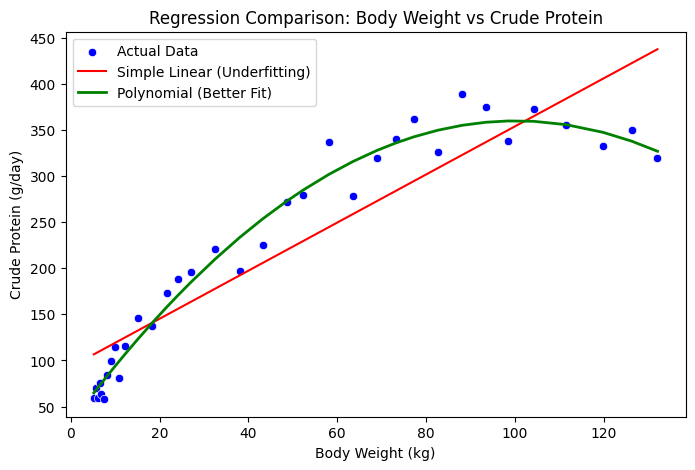

Polynomial Regression R^2: 0.9756


In [19]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features (Degree 2 allows the line to bend once)
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X_simple) # X_simple is your BW column

# Train the Polynomial Regression model
poly_reg = LinearRegression()
poly_reg.fit(X_poly, target_y) # target_y is your CP column
y_pred_poly = poly_reg.predict(X_poly)

# Sort the values so matplotlib draws a smooth, connected curve instead of a messy web
sorted_zip = sorted(zip(X_simple['BW'], y_pred_poly))
x_plot, y_poly_plot = zip(*sorted_zip)

# Plot the new Polynomial fit over your data
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['BW'], y=df['CP'], color='blue', label='Actual Data')
plt.plot(df['BW'], y_pred_slr, color='red', label='Simple Linear (Underfitting)')
plt.plot(x_plot, y_poly_plot, color='green', linewidth=2, label='Polynomial (Better Fit)')
plt.title('Regression Comparison: Body Weight vs Crude Protein')
plt.xlabel('Body Weight (kg)')
plt.ylabel('Crude Protein (g/day)')
plt.legend()
plt.show()

# Evaluate the new Polynomial R-squared
poly_r2 = r2_score(target_y, y_pred_poly)
print(f"Polynomial Regression R^2: {poly_r2:.4f}")

In [21]:
# PART 6: MACHINE LEARNING MODELS 

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

# 1. Scale the Data
scaler = StandardScaler()
X_multi_scaled = scaler.fit_transform(X_multi)

# 2. Model 
relu_model = MLPRegressor(
    hidden_layer_sizes=(16, 16),
    activation='relu',
    max_iter=50000,
    max_fun=100000,  
    solver='lbfgs',
    random_state=42
)

# 3. Model 2: Tanh 
tanh_model = MLPRegressor(
    hidden_layer_sizes=(16, 16),
    activation='tanh',
    max_iter=50000,
    max_fun=100000,   
    solver='lbfgs',
    random_state=42
)

# Train models
relu_model.fit(X_multi_scaled, target_y)
y_pred_relu = relu_model.predict(X_multi_scaled)

tanh_model.fit(X_multi_scaled, target_y)
y_pred_tanh = tanh_model.predict(X_multi_scaled)

print("Part 6 ML Models trained successfully without convergence errors!")

Part 6 ML Models trained successfully without convergence errors!



Performance Comparison (Predicting Crude Protein - CP):
Simple Linear Regression       | MSE: 2175.40 | R^2: 0.8353
Multiple Linear Regression     | MSE:  856.57 | R^2: 0.9352
ReLU Neural Network            | MSE:  196.91 | R^2: 0.9851
Tanh Neural Network            | MSE:  458.34 | R^2: 0.9653


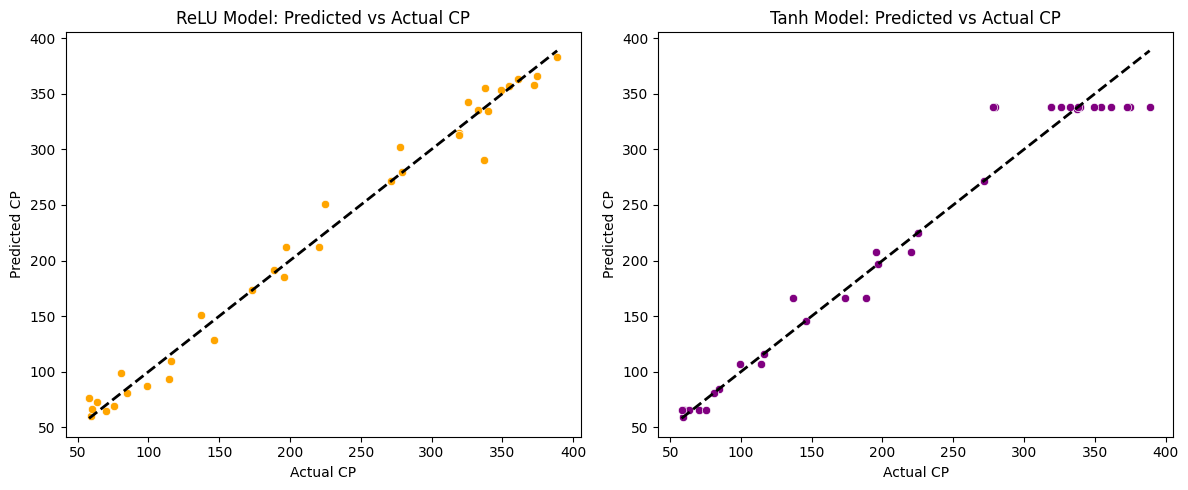

In [23]:
# PART 7: MODEL EVALUATION (Crude Protein)

models = ['Simple Linear Regression', 'Multiple Linear Regression', 'ReLU Neural Network', 'Tanh Neural Network']
predictions = [y_pred_slr, y_pred_mlr, y_pred_relu, y_pred_tanh]

print("\nPerformance Comparison (Predicting Crude Protein - CP):")
for name, pred in zip(models, predictions):
    mse = mean_squared_error(target_y, pred)
    r2 = r2_score(target_y, pred)
    print(f"{name.ljust(30)} | MSE: {mse:7.2f} | R^2: {r2:.4f}")

# Plot Predicted vs Actual for ML Models
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=target_y, y=y_pred_relu, color='orange')
plt.plot([target_y.min(), target_y.max()], [target_y.min(), target_y.max()], 'k--', lw=2)
plt.title('ReLU Model: Predicted vs Actual CP')
plt.xlabel('Actual CP')
plt.ylabel('Predicted CP')

plt.subplot(1, 2, 2)
sns.scatterplot(x=target_y, y=y_pred_tanh, color='purple')
plt.plot([target_y.min(), target_y.max()], [target_y.min(), target_y.max()], 'k--', lw=2)
plt.title('Tanh Model: Predicted vs Actual CP')
plt.xlabel('Actual CP')
plt.ylabel('Predicted CP')
plt.tight_layout()
plt.show()

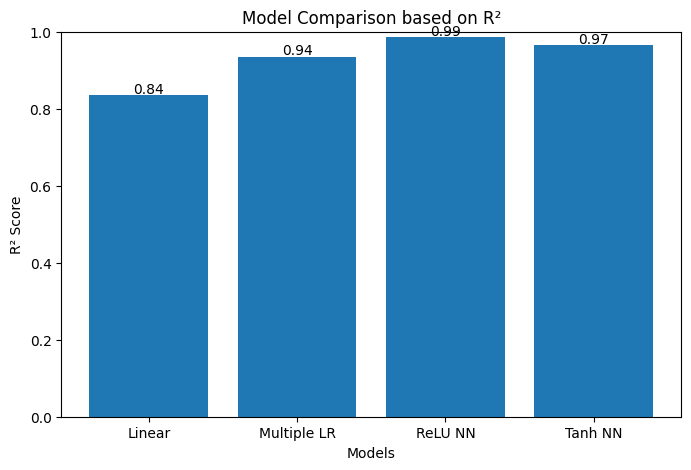

In [1]:
import matplotlib.pyplot as plt

# Replace these values with your actual R² scores
models = [
    "Linear",
    "Multiple LR",
    # "Polynomial",
    "ReLU NN",
    "Tanh NN"
]

r2_scores = [
    0.8353,   # Linear (example)
    0.9352,   # MLR
    0.9851,   # Polynomial
    0.9653,   # ReLU
  
]

# Plot
plt.figure(figsize=(8,5))
plt.bar(models, r2_scores)

# Labels
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.title("Model Comparison based on R²")

# Show values on bars
for i, v in enumerate(r2_scores):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center')

plt.ylim(0, 1)  # R² ranges from 0 to 1
plt.show()

In [21]:
# ==========================================
# PART 8: PREDICTION TASK
# ==========================================

print("\n--- Part 8: Prediction Task ---")
new_animal = pd.DataFrame({'BW': [80], 'ADG': [0.95]})
new_animal_scaled = scaler.transform(new_animal)

print(f"Predictions for an unknown pig (BW = 80 kg, ADG = 0.95 kg/day):")

for nut in nutrients:
    # Train MLR for each nutrient specifically to predict
    mlr_temp = LinearRegression().fit(X_multi, df[nut])
    relu_temp = MLPRegressor(hidden_layer_sizes=(16, 16), activation='relu', max_iter=5000, solver='lbfgs', random_state=42).fit(X_multi_scaled, df[nut])
    
    mlr_pred = mlr_temp.predict(new_animal)[0]
    relu_pred = relu_temp.predict(new_animal_scaled)[0]
    
    print(f"{nut.rjust(4)} -> MLR Predicts: {mlr_pred:7.2f} | ReLU Predicts: {relu_pred:7.2f}")
    


--- Part 8: Prediction Task ---
Predictions for an unknown pig (BW = 80 kg, ADG = 0.95 kg/day):
 DMI -> MLR Predicts:    4.17 | ReLU Predicts:    4.16
 TDN -> MLR Predicts: 2410.77 | ReLU Predicts: 2415.44
  ME -> MLR Predicts:   12.62 | ReLU Predicts:   12.40
  CP -> MLR Predicts:  338.73 | ReLU Predicts:  352.19
  DP -> MLR Predicts:  315.00 | ReLU Predicts:  325.90
  Ca -> MLR Predicts:   27.46 | ReLU Predicts:   28.61
   P -> MLR Predicts:   18.64 | ReLU Predicts:   18.58


In [23]:
# ==========================================
# PART 8: PREDICTION TASK (FIXED)
# ==========================================

print("\n--- Part 8: Prediction Task ---")

new_animal = pd.DataFrame({'BW': [80], 'ADG': [0.95]})
new_animal_scaled = scaler.transform(new_animal)

print(f"Predictions for an unknown pig (BW = 80 kg, ADG = 0.95 kg/day):")

for nut in nutrients:
    
    # Linear Regression (no scaling needed)
    mlr_temp = LinearRegression().fit(X_multi, df[nut])
    mlr_pred = mlr_temp.predict(new_animal)[0]
    
    # ReLU Model (scaled X)
    relu_temp = MLPRegressor(
        hidden_layer_sizes=(16, 16),
        activation='relu',
        max_iter=50000,
        max_fun=100000,
        solver='lbfgs',
        random_state=42
    ).fit(X_multi_scaled, df[nut])
    
    relu_pred = relu_temp.predict(new_animal_scaled)[0]
    
    print(f"{nut.rjust(4)} -> MLR Predicts: {mlr_pred:7.2f} | ReLU Predicts: {relu_pred:7.2f}")


--- Part 8: Prediction Task ---
Predictions for an unknown pig (BW = 80 kg, ADG = 0.95 kg/day):
 DMI -> MLR Predicts:    4.17 | ReLU Predicts:    4.16
 TDN -> MLR Predicts: 2410.77 | ReLU Predicts: 2415.44
  ME -> MLR Predicts:   12.62 | ReLU Predicts:   12.40
  CP -> MLR Predicts:  338.73 | ReLU Predicts:  352.19
  DP -> MLR Predicts:  315.00 | ReLU Predicts:  325.90
  Ca -> MLR Predicts:   27.46 | ReLU Predicts:   28.61
   P -> MLR Predicts:   18.64 | ReLU Predicts:   18.58
